<a href="https://colab.research.google.com/github/coder1317/AI-ML-IIIT/blob/main/AIML_Course_Probability_Primer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as pg
import plotly.express as px

In [ ]:
def toss_coin(number_of_tosses=100):
    return pd.Series(np.random.choice(['Heads', 'Tails'], number_of_tosses))
def throw_dice(number_of_tosses=100):
    return pd.Series(np.random.randint(1, 6+1, number_of_tosses))

In [ ]:
results = toss_coin()
print(results.value_counts())
fig = pg.Figure([pg.Bar(x=results.value_counts().keys(),
                        y=results.value_counts().values)])
fig.show()

Tails    59
Heads    41
Name: count, dtype: int64


In [ ]:
results = toss_coin()
print(results.value_counts())
fig = pg.Figure([pg.Bar(x=results.value_counts().keys(),
                        y=results.value_counts().values,
                        marker_color='red')]) # Added marker_color attribute
fig.show()

Heads    57
Tails    43
Name: count, dtype: int64


In [ ]:
results = pd.Series([np.sum(toss_coin(20) == 'Heads') for i in range(1000)])
fig = pg.Figure([pg.Bar(x=results.value_counts().keys(),
                        y=results.value_counts().values,
                        marker_color='red')])
fig.show()

In [ ]:
results = pd.Series([np.sum(toss_coin(500) == 'Heads') for _ in range(5000)])
fig = pg.Figure([pg.Bar(x=results.value_counts().keys(),
                        y=results.value_counts().values,
                        marker_color='green')])
fig.show()

In [ ]:
results = {shots: throw_dice(shots) for shots in [10, 100, 1000, 10000, 1000000]}
fig = pg.Figure([pg.Bar(x=result.value_counts().keys(),
                        y=result.value_counts().values / shots,)
                    for shots, result in results.items()])
fig.add_shape(type='line', x0=0.5, y0=1/6, x1=6.5, y1=1/6, line=dict(color='Black',))
fig.show()

In [ ]:
# Total cards
total_cards = 52

# Numbered cards: 2–10 → 9 cards per suit × 4 suits
numbered_cards = 9 * 4

probability = numbered_cards / total_cards
print("Probability of drawing a numbered card:", probability)

Probability of drawing a numbered card: 0.6923076923076923


In [ ]:
# Probability of numbered card
p = 36 / 52

# With replacement → independent events
probability = p * p

print("Probability (with replacement):", probability)

Probability (with replacement): 0.4792899408284023


In [ ]:
# First draw
p1 = 36 / 52

# Second draw (one numbered card removed)
p2 = 35 / 51

# Combined probability
probability = p1 * p2

print("Probability (without replacement):", probability)

Probability (without replacement): 0.4751131221719457


In [ ]:
# Same as picking a random card

numbered_cards = 36
total_cards = 52

probability = numbered_cards / total_cards

print("Probability after cutting deck:", probability)

Probability after cutting deck: 0.6923076923076923


In [ ]:
import random

# Create deck
values = ['A','2','3','4','5','6','7','8','9','10','J','Q','K']
deck = values * 4

def is_number(card):
    return card not in ['A','J','Q','K']

# Simulation
trials = 100000
count1 = count2 = count3 = count4 = 0

for _ in range(trials):
    random.shuffle(deck)

    # Task 1
    if is_number(deck[0]):
        count1 += 1

    # Task 2 (with replacement)
    if is_number(random.choice(deck)) and is_number(random.choice(deck)):
        count2 += 1

    # Task 3 (without replacement)
    if is_number(deck[0]) and is_number(deck[1]):
        count3 += 1

    # Task 4 (random cut)
    cut = random.randint(1, 52)
    if is_number(deck[cut-1]):
        count4 += 1

print("Simulated Task 1:", count1/trials)
print("Simulated Task 2:", count2/trials)
print("Simulated Task 3:", count3/trials)
print("Simulated Task 4:", count4/trials)

Simulated Task 1: 0.69202
Simulated Task 2: 0.47805
Simulated Task 3: 0.47735
Simulated Task 4: 0.69015


In [ ]:
def number_of_numbered_cards_drawn_before_ace(trials=100, show_trials=10):
    values = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K']
    ranks = ['H', 'D', 'C', 'S']

    cards_thrown_counts = []
    for experiment in range(trials):
        deck_of_cards = [value + rank for value in values for rank in ranks]
        cards_thrown = 0
        cards_pile = []
        while len(deck_of_cards) > 0:
            picked_card = np.random.choice(deck_of_cards)
            cards_pile.append(picked_card)
            if picked_card[0] == 'A':
                break
            cards_thrown += 1
            deck_of_cards.remove(picked_card)
        if experiment < show_trials:
            print(cards_thrown, 'cards were thrown:', ' '.join(cards_pile))
        cards_thrown_counts.append(cards_thrown)

    return np.mean(cards_thrown_counts), cards_thrown_counts

expected_cards_thrown, cards_thrown_counts = number_of_numbered_cards_drawn_before_ace(10000)
print(f'\n{expected_cards_thrown} cards are tossed before we see the first ace!')

7 cards were thrown: 2C 3D JS 7H QD QH 10D AD
12 cards were thrown: 7S KD 7H 4C 3C 2H KH 6C 10D 2D 9H 9S AC
32 cards were thrown: 10C 3H 8S QH 8D KC 5H JH 6S JD 4C KD 5S 8C QD 5C 5D 7H 7D 2S 4H 9D 6H 10H 9S 7S 2D KS 4S JC 2C 3C AD
7 cards were thrown: 6H 8H 5S 9H 7S 4H 10S AD
15 cards were thrown: 3S 5S KC 3C 7H 5D QH 2S 4D 7C JH 6H JD KH 4S AH
17 cards were thrown: 9S QS 2H 10D KH JH 6H 8C KC 5H 6C 4D 9C 5S 2D 4S 4C AS
11 cards were thrown: 3D 5H 7S 2D QH JC 4S 8H JS QC 9S AH
6 cards were thrown: QC 2S QS 4H KC 5H AD
17 cards were thrown: 2H 10C 5D 2C 9C 3S 10D JH 8C 9S JS 4S JD KS JC QH 4C AD
15 cards were thrown: JC 8H 2S 8C 3D 9C QS 9H KS 5S 6C QC 8S 7D 6H AS

9.6524 cards are tossed before we see the first ace!


In [ ]:
results = pd.Series(cards_thrown_counts)
fig = pg.Figure([pg.Bar(x=results.value_counts().keys(),
                        y=results.value_counts().values,
                        marker_color="red")])
fig.show()

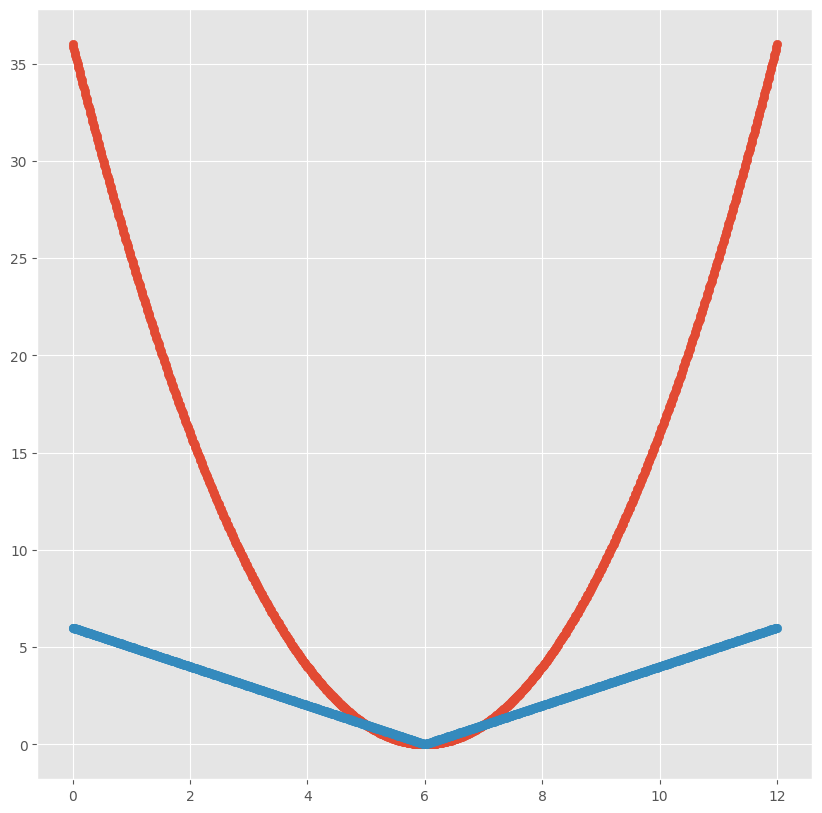

In [ ]:
from matplotlib import pyplot as plt
plt.style.use('ggplot')
plt.figure(figsize=(10, 10))

measurements = np.linspace(0, 12, 1000)
plt.scatter(measurements, (measurements - 6) ** 2, label='Squared Error')
plt.scatter(measurements, abs(measurements - 6), label='Absolute Error')
plt.show()

In [ ]:
grades = pd.read_csv("https://archive.org/download/ml-fundamentals-data/machine-learning-fundamentals-data/grades.csv")
print(grades.shape)

# Select only numeric columns
grades.select_dtypes(include="number").agg(["mean", "var", "std"])


(26, 4)


,Physics,Biology,Maths
mean,63.769231,67.038462,69.769231
var,517.224615,456.758462,300.664615
std,22.742573,21.371908,17.339683


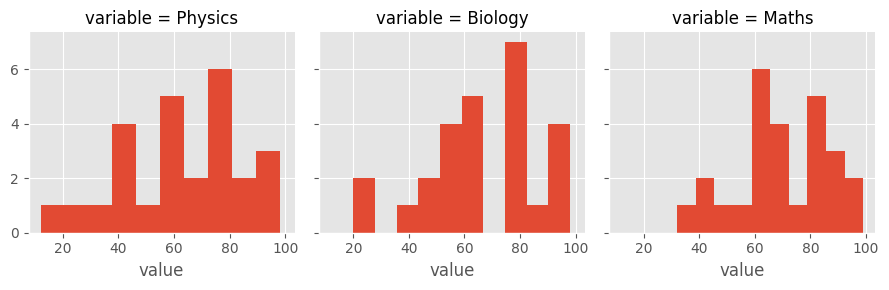

In [ ]:
g = sns.FacetGrid(grades.melt("Name"), col="variable")
g.map(plt.hist, "value")

In [ ]:
grades["Physics_std"] = (grades["Physics"] - grades["Physics"].mean()) / grades["Physics"].std()

In [ ]:
grades

,Name,Physics,Biology,Maths,Physics_std
0,Arnold,80,78,70,0.713673
1,Bob,60,98,45,-0.165735
2,Cassandra,34,56,65,-1.308965
3,Donovan,56,65,32,-0.341616
4,Emily,98,23,55,1.505141
5,Fabian,45,44,60,-0.825291
6,Grom,12,66,80,-2.276314
7,Hilary,60,88,78,-0.165735
8,Ivan,45,97,99,-0.825291
9,John,98,80,84,1.505141


In [ ]:
grades["Maths_std"] = (grades["Maths"] - grades["Maths"].mean()) / grades["Maths"].std()
grades

,Name,Physics,Biology,Maths,Physics_std,Maths_std
0,Arnold,80,78,70,0.713673,0.013309
1,Bob,60,98,45,-0.165735,-1.428471
2,Cassandra,34,56,65,-1.308965,-0.275047
3,Donovan,56,65,32,-0.341616,-2.178196
4,Emily,98,23,55,1.505141,-0.851759
5,Fabian,45,44,60,-0.825291,-0.563403
6,Grom,12,66,80,-2.276314,0.590021
7,Hilary,60,88,78,-0.165735,0.474678
8,Ivan,45,97,99,-0.825291,1.685773
9,John,98,80,84,1.505141,0.820705


In [ ]:
from scipy.stats import binom
binom.pmf(k=5, n=5, p=0.25)
1 - binom.pmf(k=4, n=5, p=0.75) - binom.pmf(k=5, n=5, p=0.75)

np.float64(0.3671875)

In [ ]:
binom.cdf(3, n=5, p=0.75)

np.float64(0.3671875)

In [ ]:
from scipy.stats import norm

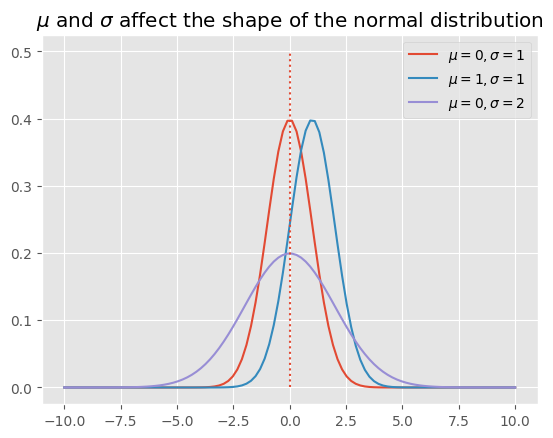

In [ ]:
#Standard normal distribution
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-10, 10, 100)
f1 = norm.pdf(x, loc=0, scale=1)
f2 = norm.pdf(x, loc=1, scale=1)
f3 = norm.pdf(x, loc=0, scale=2)

plt.plot(x, f1, label=r"$\mu=0, \sigma=1$")
plt.plot(x, f2, label=r"$\mu=1, \sigma=1$")
plt.plot(x, f3, label=r"$\mu=0, \sigma=2$")
plt.vlines(x=0, ymin=0, ymax=0.5, linestyles="dotted")

plt.legend()
plt.title(r"$\mu$ and $\sigma$ affect the shape of the normal distribution")
plt.show()


In [ ]:
norm.cdf(0)

np.float64(0.5)

In [ ]:
norm.ppf(0.5)

np.float64(0.0)

In [ ]:
#Thinking with the Empirical Rule:
print(norm.ppf(0.84, loc=169.57, scale=7.57))
169.57 + 7.57

177.09804617589782


177.14

In [ ]:
#Thinking with the Empirical Rule:
print(norm.ppf(0.975, loc=169.57, scale=7.57))
169.57 + 2 * 7.57

184.4069273629682


184.70999999999998

In [ ]:
print(norm.ppf(0.0015, loc=169.57, scale=7.57))
169.57 - 3 * 7.57

147.10422390516268


146.85999999999999

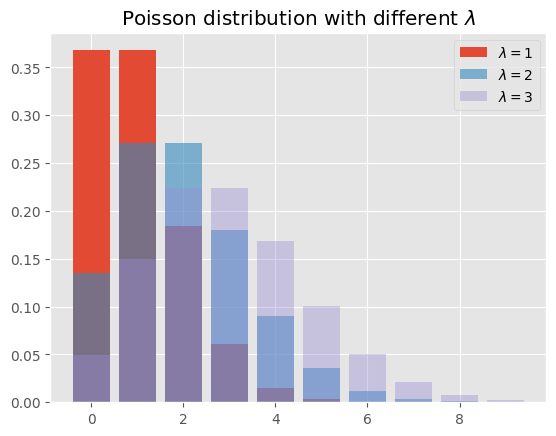

In [ ]:
#Poisson distribution
# a Poisson distribution with lambda=1 can be interpreted as:
# on average, 1 event occurs within the set time interval.
# naturally, it is less likely that more than 1 event occurs.

from scipy.stats import poisson

# Poisson distribution with different λ values
x = np.arange(10)
f1 = poisson.pmf(x, mu=1)
f2 = poisson.pmf(x, mu=2)
f3 = poisson.pmf(x, mu=3)

plt.bar(x, f1, label=r"$\lambda=1$")
plt.bar(x, f2, label=r"$\lambda=2$", alpha=0.6)
plt.bar(x, f3, label=r"$\lambda=3$", alpha=0.4)

plt.legend()
plt.title(r"Poisson distribution with different $\lambda$")
plt.show()

In [ ]:
# the average can be calculated by multiplying the inputs with the values of the PMF
x @ f1
# see that this is equal to lambda

np.float64(0.999998874797402)

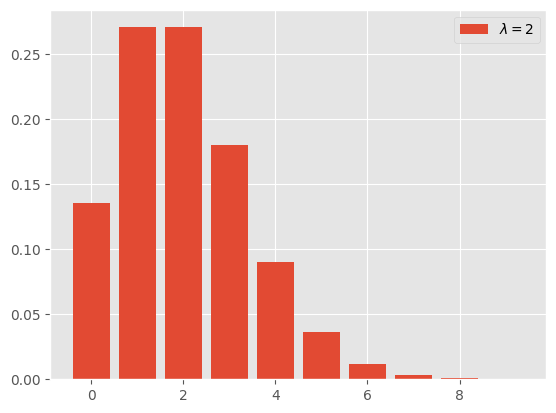

In [ ]:
# for lambda=2, having 2 events is a lot more likely

plt.bar(x, f2, label=r"$\lambda=2$")
plt.legend()

In [ ]:
x @ f2

np.float64(1.999525105343477)

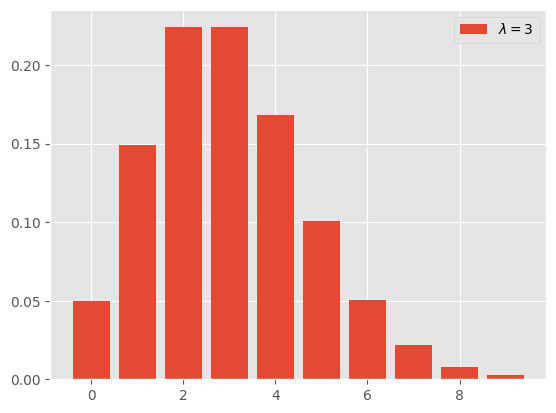

In [ ]:
plt.bar(x, f3, label=r"$\lambda=3$")
plt.legend()

In [ ]:
x @ f3

np.float64(2.9885910238149727)

In [ ]:
poisson.pmf(3, 5)

np.float64(0.1403738958142805)

**The Result**

The histogram of sample means will look like a normal distribution,
even though the original population was not normal!

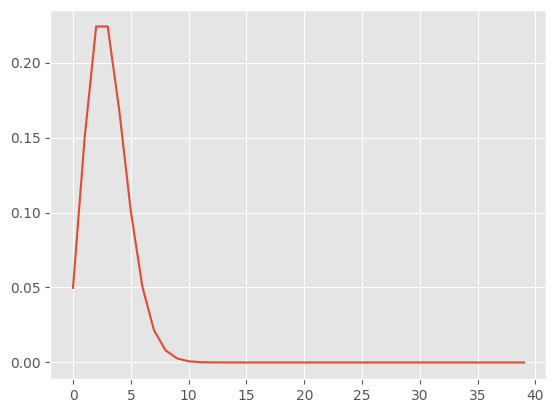

In [ ]:
from scipy.stats import poisson
bins = np.arange(0, 40)
p_pois = poisson.pmf(bins, mu=3)
plt.plot(bins, p_pois)

(array([ 7.,  5., 45., 55., 64., 93., 72., 44.,  8.,  7.]),
 array([1.9 , 2.12, 2.34, 2.56, 2.78, 3.  , 3.22, 3.44, 3.66, 3.88, 4.1 ]),
 <BarContainer object of 10 artists>)

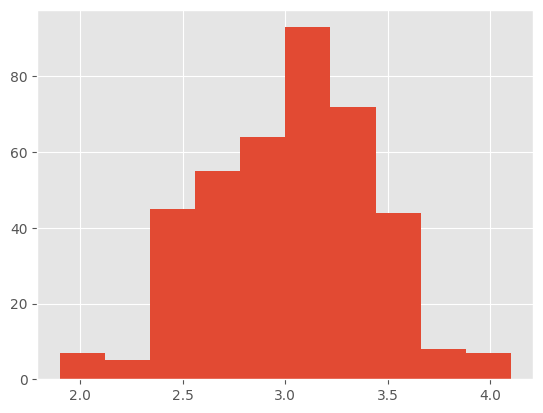

In [ ]:
def sample_pois(_):
    samples = poisson.rvs(mu=3, size=20)
    return np.mean(samples)

means = list(map(sample_pois, np.arange(400)))
plt.hist(means)

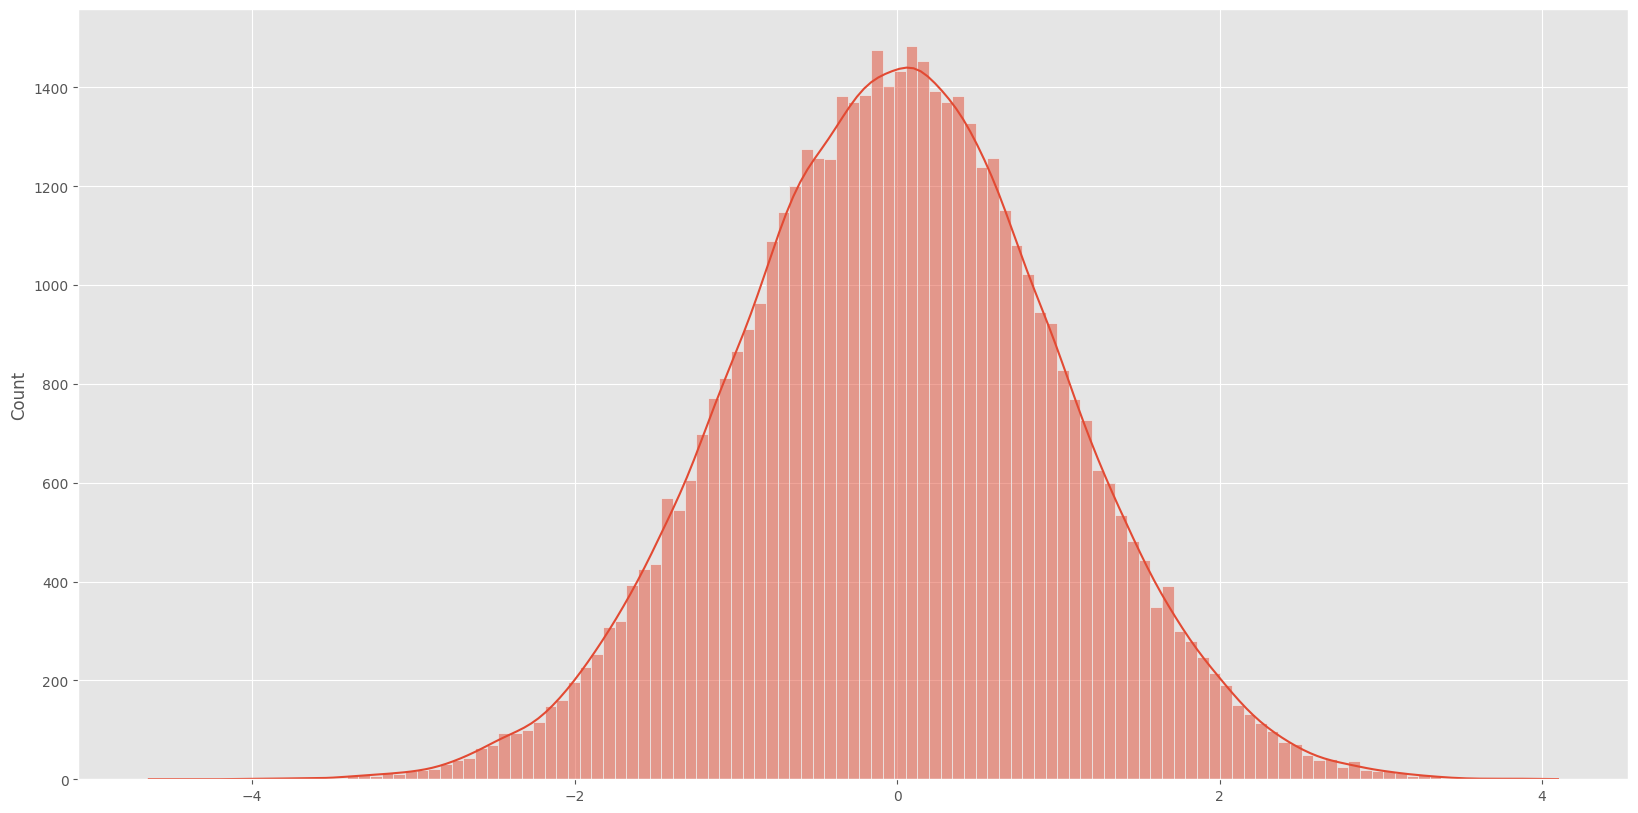

In [ ]:
import seaborn as sns
plt.figure(figsize=(20, 10))
x = np.random.normal(size=(50000))
sns.histplot(x, kde=True)
plt.show()

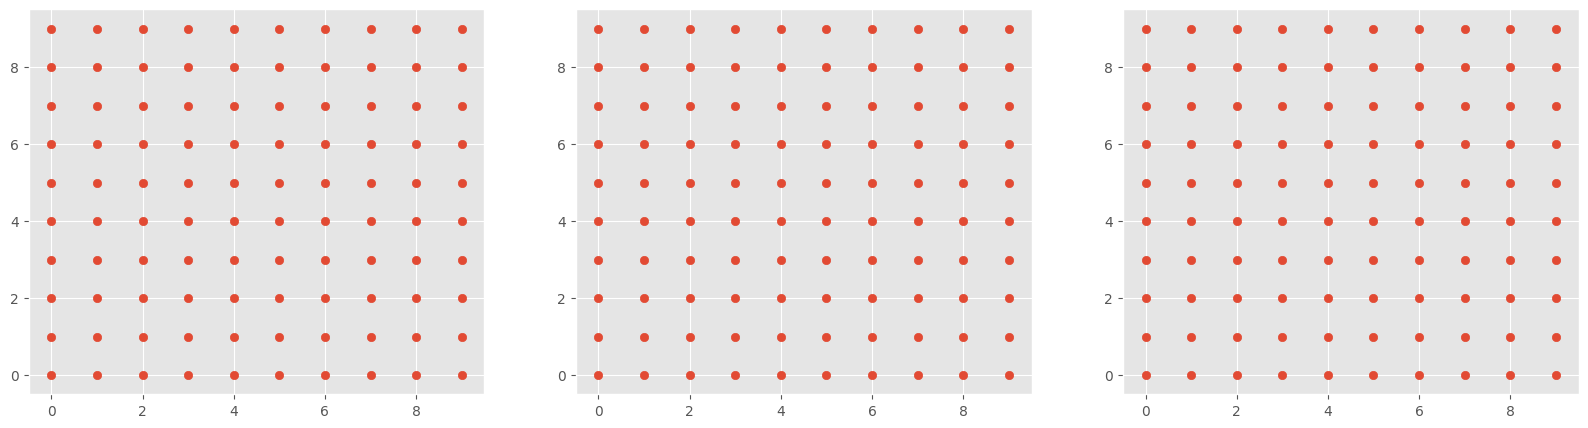

In [ ]:
fix, axs = plt.subplots(1, 3, figsize=(20, 5))

for ax in axs:
    x, y = np.meshgrid(np.arange(10), np.arange(10))
    ax.scatter(x.ravel(), y.ravel())
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)

plt.show()

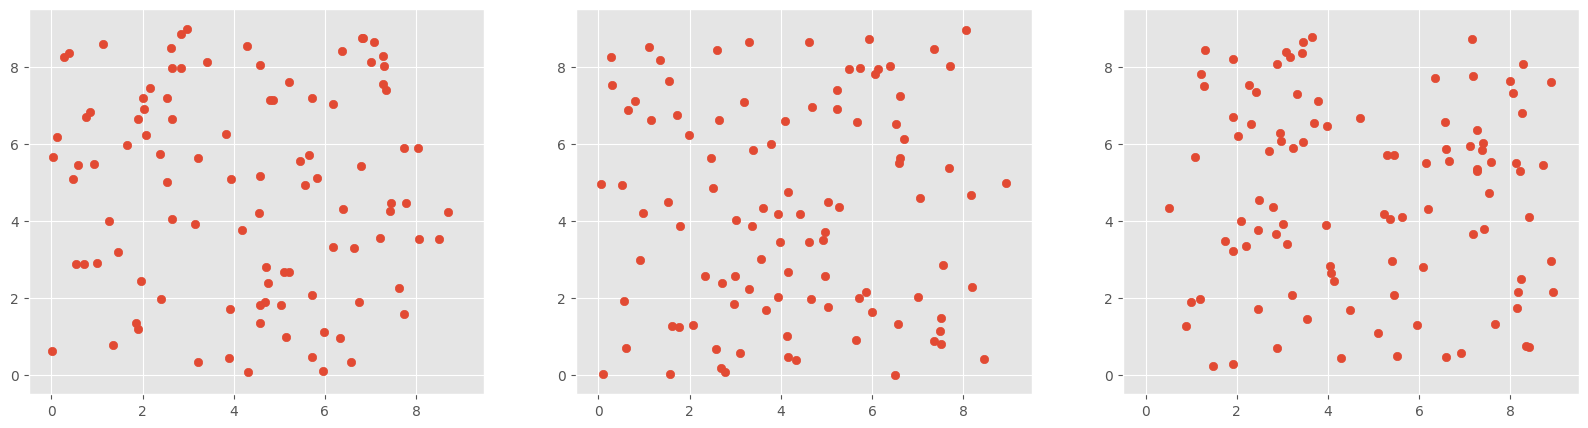

In [ ]:
fix, axs = plt.subplots(1, 3, figsize=(20, 5))

for ax in axs:
    x, y = np.random.random(100) * 9, np.random.random(100) * 9
    ax.scatter(x.ravel(), y.ravel())
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)

plt.show()

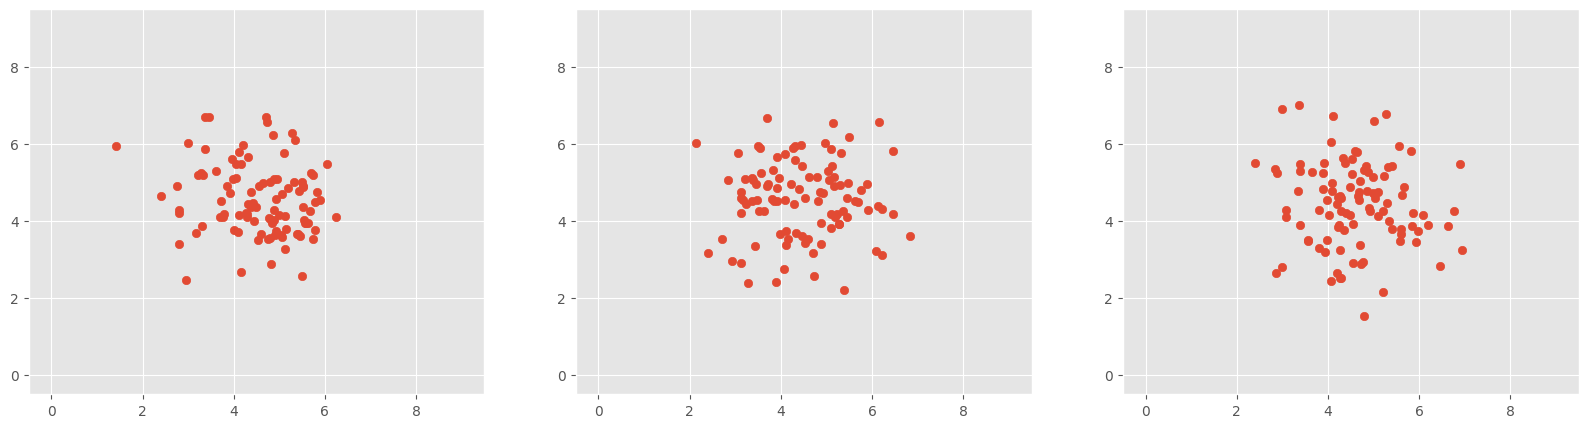

In [ ]:
fix, axs = plt.subplots(1, 3, figsize=(20, 5))

for ax in axs:
    x, y = np.random.normal(loc=4.5, scale=1.0, size=100), np.random.normal(loc=4.5, scale=1.0, size=100)
    ax.scatter(x.ravel(), y.ravel())
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)

plt.show()